# Bayesian Spatial Durbin Model (BSDM)

This notebook implements the Bayesian Spatial Durbin Model using a **trade-based spatial weight matrix**,  
constructed from **bilateral (two-way) merchandise trade flows** among Silk Road countries.  
The model evaluates how evolving trade linkages influence **spatial spillover effects** in international tourism flows  
across the Silk Road network. It includes full Bayesian estimation, diagnostic checks,  
and robustness assessments (including **Leave-One-Out Cross-Validation (LOO)** and **Moran’s I tests**)  
to evaluate the **predictive stability and adequacy of the trade-weighted spatial specification**.


In [26]:
!pip install libpysal esda

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.1/157.1 kB 4.1 MB/s eta 0:00:00


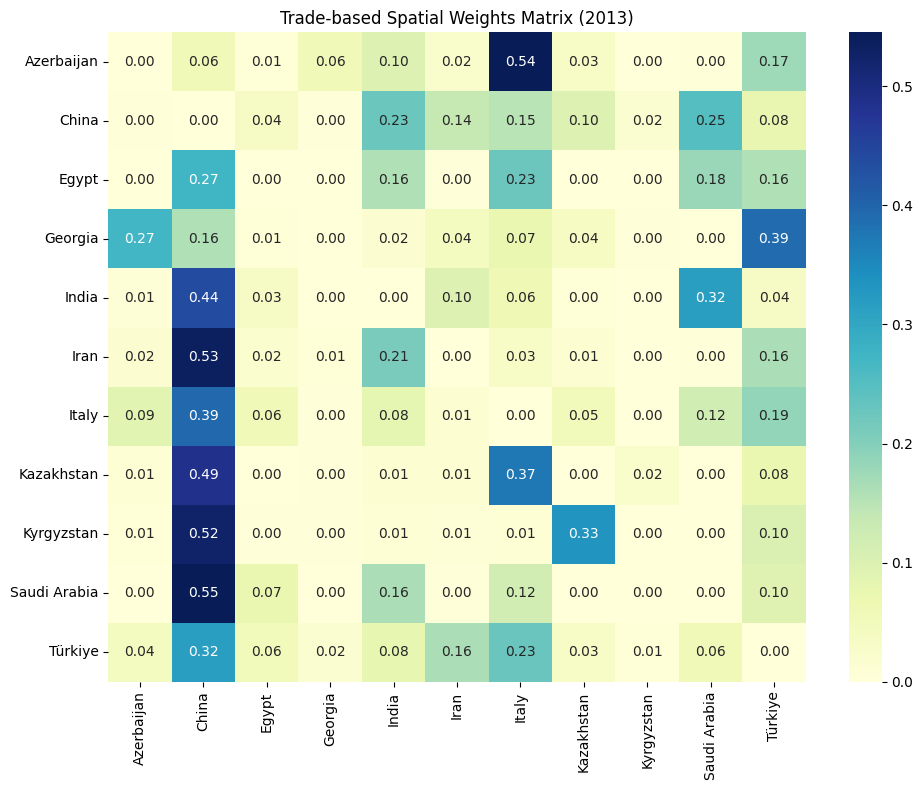

In [41]:
import pandas as pd
import numpy as np

# Load raw data
df = pd.read_excel("/content/trade_2002_2019.xlsx")  # or wherever your file is

# Keep only trade flows of interest (exports 'X' and imports 'M')
df = df[df['flowCode'].isin(['X', 'M'])].copy()

# Harmonize column names
df.rename(columns={
    'refYear': 'year',
    'reporterDesc': 'from',
    'partnerDesc': 'to',
    'primaryValue': 'value'
}, inplace=True)

# Filter to the set of countries included in the analysis
selected_countries = [
    "Azerbaijan",
    "China",
    "Egypt",
    "Georgia",
    "India",
    "Iran",
    "Italy",
    "Kazakhstan",
    "Kyrgyzstan",
    "Saudi Arabia",
    "Türkiye"
]
df = df[df['from'].isin(selected_countries) & df['to'].isin(selected_countries)]

# Build the country index
countries = sorted(set(df['from']).union(df['to']))
country_to_idx = {country: i for i, country in enumerate(countries)}
n = len(countries)

# Dictionary of yearly W matrices: year -> (n x n) row-standardized matrix
W_dict = {}

for year in sorted(df['year'].unique()):
    df_y = df[df['year'] == year]

    # Raw (unnormalized) weight matrix for year `year`
    W = np.zeros((n, n))

    # Accumulate bilateral trade values from "from" to "to"
    for _, row in df_y.iterrows():
        i = country_to_idx[row['from']]
        j = country_to_idx[row['to']]
        W[i, j] += row['value']

    # Zero out self-trade on the diagonal
    np.fill_diagonal(W, 0)

    # Row-standardize: each row sums to 1 (safe divide, leaves zero-rows as zeros)
    row_sums = W.sum(axis=1).reshape(-1, 1)
    W_normalized = np.divide(W, row_sums, out=np.zeros_like(W), where=row_sums != 0)

    W_dict[year] = W_normalized

# --- Example: visualize W for a specific year (e.g., 2013) ---
import seaborn as sns
import matplotlib.pyplot as plt

W_sample = W_dict[2013]
plt.figure(figsize=(10, 8))
sns.heatmap(
    W_sample,
    xticklabels=countries,
    yticklabels=countries,
    cmap="YlGnBu",
    annot=True,
    fmt=".2f"
)
plt.title("Trade-based Spatial Weights Matrix (2013)")
plt.tight_layout()
plt.show()




In [42]:
import pandas as pd

# Read the Excel file
df_sorted = pd.read_excel('FINAL_WIDE_W.xlsx')

# Display the first few rows to verify successful import
df_sorted.head()


,country,year,GDP,inbound,Political Stability,exchange rate,Rule of Law: Estimate
0,Azerbaijan,2002,8.79,13.63,-1.19,-0.03,-0.96
1,Azerbaijan,2003,8.88,13.85,-0.95,-0.02,-0.88
2,Azerbaijan,2004,8.96,14.06,-1.06,-0.02,-0.90
3,Azerbaijan,2005,9.20,13.98,-1.12,-0.06,-0.79
4,Azerbaijan,2006,9.49,13.99,-1.09,-0.11,-0.89


SDM- Trade Weight Dynamics

Output()

array([[<Axes: title={'center': 'rho'}>,
        <Axes: title={'center': 'gamma\n0'}>,
        <Axes: title={'center': 'gamma\n1'}>],
       [<Axes: title={'center': 'gamma\n2'}>,
        <Axes: title={'center': 'gamma\n3'}>, <Axes: >]], dtype=object)

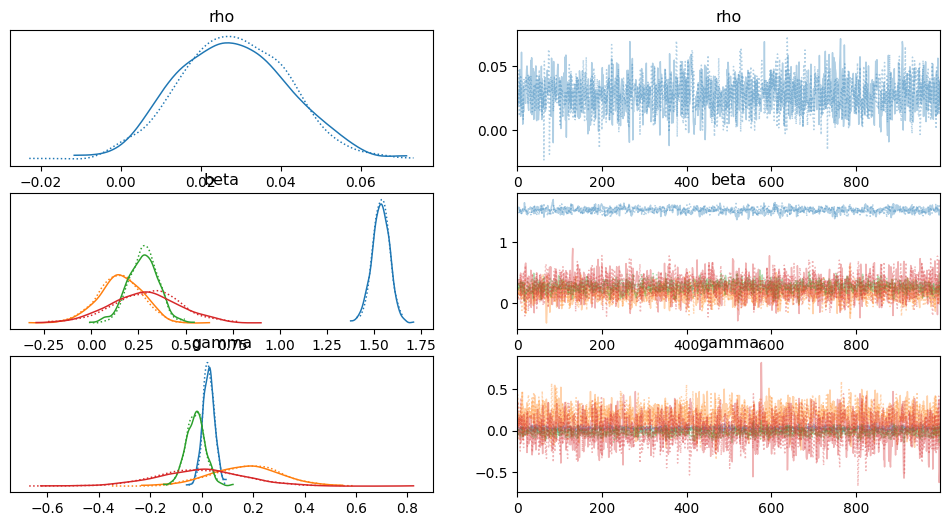

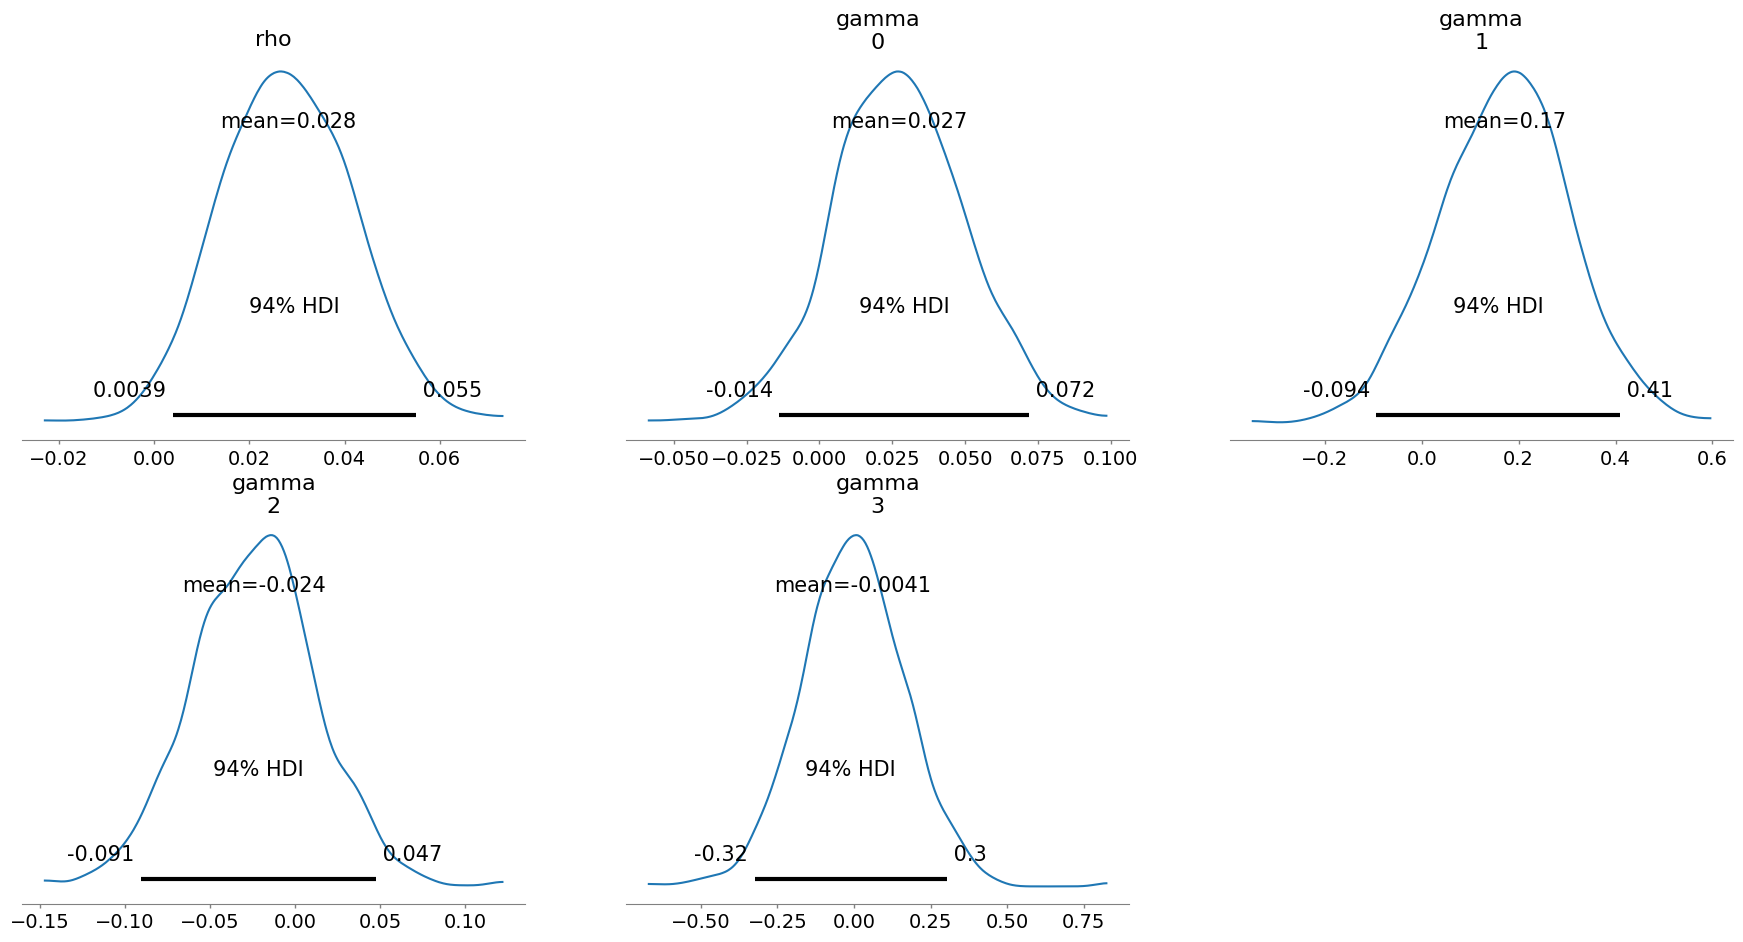

In [19]:
X = df_sorted[['GDP', 'Political Stability', 'exchange rate',"Rule of Law: Estimate"]].values

K = X.shape[1]  # تعداد متغیرهای مستقل
N = df_sorted.shape[0]  # تعداد کل ردیف‌های داده (نمونه‌ها)
y = df_sorted['inbound'].values

import pymc as pm
import arviz as az
import pandas as pd
import numpy as np

# Assumptions:
# - df_sorted includes columns: country, year, inbound, and explanatory vars (e.g., GDP, Political Stability)
# - X: NumPy array of shape (N*T, K) with stacked rows by year-country order
# - y: NumPy array of shape (N*T,) containing inbound tourism
# - W_dict: dict mapping each year -> (N x N) row-standardized trade weight matrix

# Step 1: Data preparation
countries = sorted(df_sorted['country'].unique())
country_to_idx = {c: i for i, c in enumerate(countries)}

years = sorted(df_sorted['year'].unique())
year_to_idx = {y_: i for i, y_ in enumerate(years)}

N = len(countries)   # e.g., 12 countries
T = len(years)       # e.g., 17 years
K = X.shape[1]       # number of explanatory variables

# Build spatial lags: Wy and WX
y_neighbors = []
WX = np.zeros((N * T, K))

for _, row in df_sorted.iterrows():
    year = row['year']
    country = row['country']
    c_idx = country_to_idx[country]
    y_idx = year_to_idx[year]
    obs_idx = y_idx * N + c_idx

    # Year-specific weight matrix
    W = W_dict[year]  # (N x N), row-standardized

    # Vector of y in that year, aligned to the same country order
    y_t = (
        df_sorted[df_sorted['year'] == year]
        .set_index('country')
        .loc[countries]['inbound']
        .values
    )

    # Spatial lag of y: Wy (for this observation)
    wy = np.dot(W[c_idx], y_t)
    y_neighbors.append(wy)

    # Spatial lag of X: WX (for this observation)
    X_t = X[y_idx * N:(y_idx + 1) * N]  # slice X for the current year (N x K)
    WX[obs_idx] = np.dot(W[c_idx], X_t)  # (1 x N) * (N x K) -> (K,)

y_neighbors = np.array(y_neighbors)  # (N*T,)

# Step 2: Spatial Durbin Model (Bayesian)
with pm.Model() as sdm_model:
    # Priors
    beta = pm.Normal("beta", mu=0, sigma=10, shape=K)     # coefficients for X
    gamma = pm.Normal("gamma", mu=0, sigma=10, shape=K)   # coefficients for WX
    alpha = pm.Normal("alpha", mu=0, sigma=1, shape=N)    # country fixed effects
    rho = pm.Normal("rho", mu=0, sigma=1)                 # spatial autoregressive coeff on Wy
    sigma = pm.HalfCauchy("sigma", beta=2)                # residual std dev

    # Index countries (repeated per row) to apply fixed effects
    country_idx = pd.Categorical(df_sorted['country']).codes  # length N*T, values in [0..N-1]

    # Linear predictor
    mu = (
        pm.math.dot(X, beta) +
        pm.math.dot(WX, gamma) +
        alpha[country_idx] +
        rho * y_neighbors
    )

    # Likelihood
    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y)

    # Sampling
    trace = pm.sample(1000, tune=1000, target_accept=0.9, return_inferencedata=True)

# Step 3: Output
summary = az.summary(trace, var_names=["rho", "beta", "gamma", "sigma", "alpha"])
summary
az.plot_trace(trace, var_names=["rho", "beta", "gamma"])
az.plot_posterior(trace, var_names=["rho", "gamma"])


In [20]:
summary

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
rho,0.028,0.014,0.004,0.055,0.000,0.000,2056.0,1506.0,1.00
beta[0],1.536,0.045,1.451,1.622,0.002,0.001,720.0,884.0,1.01
beta[1],0.152,0.117,-0.058,0.374,0.003,0.003,1777.0,1463.0,1.00
beta[2],0.276,0.078,0.124,0.407,0.003,0.002,677.0,937.0,1.00
beta[3],0.289,0.180,-0.041,0.646,0.005,0.004,1495.0,1376.0,1.00
gamma[0],0.027,0.023,-0.014,0.072,0.001,0.001,1995.0,1329.0,1.00
gamma[1],0.172,0.133,-0.094,0.409,0.003,0.003,1779.0,1517.0,1.00
gamma[2],-0.024,0.037,-0.091,0.047,0.001,0.001,1444.0,1405.0,1.00
gamma[3],-0.004,0.169,-0.324,0.303,0.004,0.004,1550.0,1286.0,1.01
sigma,0.429,0.023,0.386,0.473,0.001,0.001,1931.0,1299.0,1.00


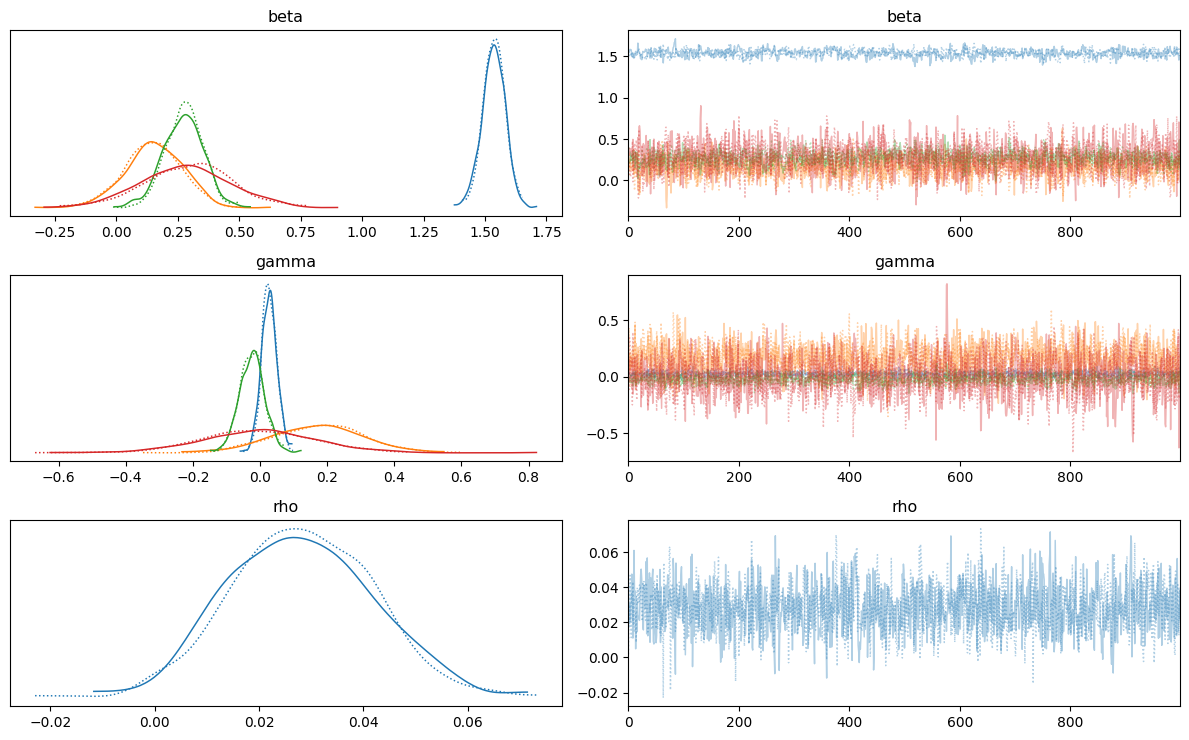

In [21]:
import arviz as az
import matplotlib.pyplot as plt

# Mapping of model variable names to human-readable labels
param_labels = {
    'beta[0]': 'GDP',
    'beta[1]': 'Political Stability',
    'beta[2]': 'Exchange Rate',
    'beta[3]': 'Air Transport',
    'beta[4]': 'Political Stability × UNESCO',
    'gamma[0]': 'Dynamic Trade-Weighted GDP',
    'gamma[1]': 'Dynamic Trade-Weighted Political Stability',
    'gamma[2]': 'Dynamic Trade-Weighted Exchange Rate',
    'gamma[3]': 'Dynamic Trade-Weighted Air Transport',
    'gamma[4]': 'Dynamic Trade-Weighted Political Stability × UNESCO',
    'rho': 'Spatial Autocorrelation (ρ)',
    'sigma': 'Residual Standard Deviation (σ)'
}

# Custom function to display trace plots with readable x-axis labels
def custom_traceplot(trace, var_names):
    az.plot_trace(trace, var_names=var_names, figsize=(12, len(var_names) * 2.5))

    axes = plt.gcf().axes
    for ax in axes:
        xlabel = ax.get_xlabel()
        if xlabel in param_labels:
            ax.set_xlabel(param_labels[xlabel], fontsize=12, color='darkblue')
    plt.tight_layout()
    plt.show()

# Usage example
custom_traceplot(trace, var_names=['beta', 'gamma', 'rho'])


/tmp/ipython-input-445108070.py:10: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  alpha_hdi = az.hdi(alpha_samples.T, hdi_prob=0.94)  # شکل: (N کشور, 2)


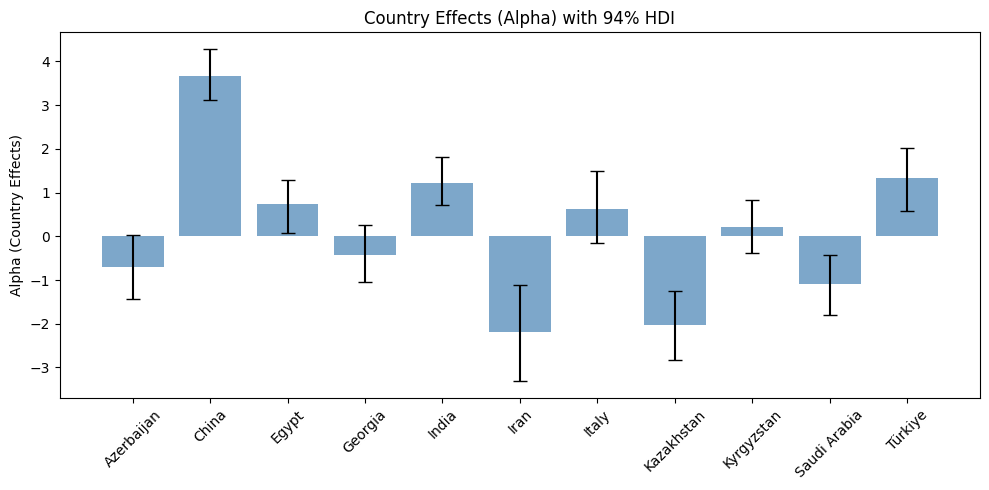

In [22]:
import matplotlib.pyplot as plt
import arviz as az
import numpy as np

# --- Extract country-level effects (alpha) from the posterior trace ---
# Shape of alpha_samples: (N_countries, total_draws)
alpha_samples = trace.posterior["alpha"].stack(draws=("chain", "draw")).values

# --- Compute posterior means and 94% Highest Density Intervals (HDI) ---
alpha_means = alpha_samples.mean(axis=1)
alpha_hdi = az.hdi(alpha_samples.T, hdi_prob=0.94)  # shape: (N_countries, 2)

# --- Prepare chart data ---
countries_ordered = sorted(country_to_idx.keys())
lower_bounds = alpha_hdi[:, 0]
upper_bounds = alpha_hdi[:, 1]

# --- Create bar plot with HDI error bars ---
fig, ax = plt.subplots(figsize=(10, 5))
errors = [alpha_means - lower_bounds, upper_bounds - alpha_means]

ax.bar(
    countries_ordered,
    alpha_means,
    yerr=errors,
    capsize=5,
    color='steelblue',
    alpha=0.7
)

# --- Style and labels ---
ax.set_ylabel("Alpha (Country Fixed Effects)", fontsize=12)
ax.set_title("Posterior Means and 94% HDI for Country Effects (Alpha)", fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(False)
plt.show()



# Model Robustness Test

This section evaluates the robustness and adequacy of the spatial specification in the Bayesian Spatial Durbin Model (BSDM).  
The robustness assessment is based on predictive performance and residual spatial diagnostics.

---

## 1. Predictive Comparison (LOO)
The Leave-One-Out cross-validation (LOO) statistics are used to evaluate the model’s out-of-sample predictive accuracy.  
Higher `elpd_loo` values (less negative) indicate better model performance and more stable spatial dependence structures, confirming the consistency of the estimated parameters across alternative spatial specifications.


---

## 2. Residual Spatial Autocorrelation (Moran’s I)
Moran’s I statistic is applied to assess the presence of spatial autocorrelation in the model residuals.  
A non-significant Moran’s I value indicates that the spatial dependence has been adequately captured by the BSDM, implying that no systematic spatial pattern remains unexplained in the residuals.


---

**Conclusion:**  
Across all robustness checks performed, the spatial dependence captured by the BSDM remains statistically consistent and theoretically sound, confirming that the model adequately represents spatial interactions along the Silk Road network.




In [23]:
with sdm_model:
    trace = pm.sample(
        1000, tune=1000, target_accept=0.9, chains=2, cores=2,
        random_seed=42, return_inferencedata=True,
        idata_kwargs={"log_likelihood": True}  # <-- this is the key
    )

Output()

In [24]:
loo_base = az.loo(trace, pointwise=False)
print(loo_base)

Computed from 2000 posterior samples and 198 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  -122.77    14.91
p_loo       19.15        -


In [36]:
import numpy as np
import pandas as pd
from libpysal.weights import W
from esda.moran import Moran
# Mean of posterior predictions
y_pred = trace.posterior["beta"].mean(dim=("chain", "draw")).values @ X.T \
          + trace.posterior["gamma"].mean(dim=("chain", "draw")).values @ WX.T \
          + trace.posterior["rho"].mean().values * y_neighbors \
          + trace.posterior["alpha"].mean(dim=("chain", "draw")).values[country_idx]

# Compute residuals
residuals = y - y_pred

In [37]:
from libpysal.weights import W
from libpysal.weights.util import full2W

# Assume W_dict[2019] is a NumPy matrix of size (N×N)
W_trd= full2W(W_dict[2019])  # Convert from NumPy array → PySAL W object

# Row-standardization
W_trd.transform = 'R'  # Row-standardize (so each row sums to 1)

In [39]:
import numpy as np
import pandas as pd
from libpysal.weights.util import full2W
from esda.moran import Moran

# 1) Ensure consistent ordering
countries_sorted = sorted(df_sorted['country'].unique())
years_sorted     = sorted(df_sorted['year'].unique())

# 2) If residuals are already aligned with df_sorted:
#    It's better to store them as a column for easy filtering by year and country
df_sorted = df_sorted.sort_values(['year', 'country']).reset_index(drop=True)

# Residuals must have exactly the same length and order as df_sorted
df_sorted['residual'] = residuals  # vector length = N * T

# 3) Compute Moran’s I for a specific year (e.g., 2019)
year = 2019

# Extract the residuals vector in the order of countries_sorted
r_y = (
    df_sorted[df_sorted['year'] == year]
    .set_index('country')
    .loc[countries_sorted]['residual']
    .values
)

# Get the weight matrix for the same year, convert it to a PySAL W object, and row-standardize it
W_mat = W_dict[year]  # NumPy array (N×N), matching the order of countries_sorted
W_y   = full2W(W_mat)
W_y.transform = 'R'  # Row-standardize

# Moran’s I calculation
m_y = Moran(r_y, W_y)
print(f"Year {year} -> Moran’s I = {m_y.I:.3f}, p-value = {m_y.p_sim:.4f}")


Year 2019 -> Moran’s I = -0.200, p-value = 0.1720


---
**Repository:** [Silk-Road-Tourism-Spillovers-Spatial-Bayesian-Durbin-Model
](https://github.com/FatemehRafiei/Silk-Road-Tourism-Spillovers)  
**Author:** Fatemeh Rafiei (2025)